# EP15 — Monte Carlo Tree Search (MCTS)
**COMPSCI 713 · S1 2025 Q6 · 2 marks**

**Question:** MCTS combines two important ideas: *selective search* and *evaluation by rollouts*. Discuss briefly how these two concepts relate to the way MCTS explores a search tree.

---

## MCTS — Core Answer

### Selective Search
MCTS does **not** explore the tree uniformly. Instead, it concentrates effort on the most *promising* branches using the **UCB1 (Upper Confidence Bound)** formula:

```
UCB1(node) = Q(node)/N(node) + C × √(ln(N_parent) / N(node))
```

- **Q/N** = exploitation: prefer nodes with a high win rate so far
- **√(ln(N_parent)/N)** = exploration: prefer nodes that have been visited fewer times

This means MCTS focuses computing power on branches that are both *likely good* and *insufficiently explored* — it avoids wasting time on branches that are clearly bad.

### Evaluation by Rollouts (Simulation)
Once a new node is reached, MCTS cannot afford a full minimax search from there (too expensive). Instead, it estimates the node's value by running a **random rollout (playout)**:
- From the new node, simulate the rest of the game with random moves until the game ends
- Record the outcome (win/loss/draw)
- This outcome is an *unbiased* (but noisy) estimate of the node's true value
- The estimate is back-propagated up the tree, updating Q and N for all ancestors

### How They Work Together
1. **Select** — use UCB1 to pick the most promising unexplored node (selective search)
2. **Expand** — add that node to the tree
3. **Simulate** — run a random rollout from the new node (evaluation by rollout)
4. **Backpropagate** — update win statistics up the tree

Repeat thousands of times. Selective search ensures the budget is concentrated where it matters; rollouts provide a cheap, unbiased signal to guide that selection — without needing a hand-crafted evaluation function.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import log, sqrt

np.random.seed(42)

# =============================================================
# Minimal MCTS implementation on a simple 2-player game
# Game: coin toss race to 3 — trivial, but shows MCTS mechanics
# =============================================================

class MCTSNode:
    def __init__(self, state, parent=None, action=None):
        self.state    = state       # game state
        self.parent   = parent
        self.action   = action      # action that led here
        self.children = []
        self.N = 0    # visit count
        self.Q = 0.0  # total value (wins)

    def ucb1(self, C=1.41):
        if self.N == 0:
            return float('inf')  # unvisited: explore first
        return self.Q / self.N + C * sqrt(log(self.parent.N) / self.N)

    def is_leaf(self):
        return len(self.children) == 0


# ---- Simple game: player picks from 3 arms (actions 0,1,2) ----
# True win rates (unknown to MCTS)
TRUE_WIN_RATES = [0.3, 0.7, 0.5]

def get_actions(state):
    """All states have 3 actions for simplicity."""
    return [0, 1, 2]

def is_terminal(state):
    return state['depth'] >= 3  # explore 3 levels deep

def rollout(state):
    """Random rollout — simulate to end with random actions."""
    current = dict(state)
    while not is_terminal(current):
        action = np.random.choice(get_actions(current))
        win    = np.random.rand() < TRUE_WIN_RATES[action]
        current = {'depth': current['depth'] + 1, 'wins': current['wins'] + win}
    return current['wins'] / current['depth']

def mcts(n_iterations=500):
    root = MCTSNode({'depth': 0, 'wins': 0})
    visit_log = []

    for i in range(n_iterations):
        # 1. SELECTION — traverse tree using UCB1
        node = root
        while not node.is_leaf() and not is_terminal(node.state):
            node = max(node.children, key=lambda c: c.ucb1())

        # 2. EXPANSION — add children if not terminal
        if not is_terminal(node.state) and node.N > 0:
            for action in get_actions(node.state):
                child_state = {'depth': node.state['depth'] + 1,
                               'wins':  node.state['wins']}
                node.children.append(MCTSNode(child_state, parent=node, action=action))
            node = node.children[0]

        # 3. SIMULATION — rollout from this node
        value = rollout(node.state)

        # 4. BACKPROPAGATION — update ancestors
        current = node
        while current is not None:
            current.N += 1
            current.Q += value
            current = current.parent

        # Log action visit counts at root level
        if root.children:
            visit_log.append([c.N for c in root.children])

    return root, visit_log

root, visit_log = mcts(500)

print('=== MCTS Results ===')
print(f'Root visits: {root.N}')
if root.children:
    for c in root.children:
        print(f'  Action {c.action}: N={c.N:3d}, Q/N={c.Q/max(c.N,1):.3f}  '
              f'(true win rate: {TRUE_WIN_RATES[c.action]})')
    best = max(root.children, key=lambda c: c.Q / max(c.N, 1))
    print(f'\nBest action selected: {best.action} '
          f'(true best: {np.argmax(TRUE_WIN_RATES)})')

=== MCTS Results ===
Root visits: 500
  Action 0: N=166, Q/N=0.006  (true win rate: 0.3)
  Action 1: N=169, Q/N=0.008  (true win rate: 0.7)
  Action 2: N=164, Q/N=0.004  (true win rate: 0.5)

Best action selected: 1 (true best: 1)


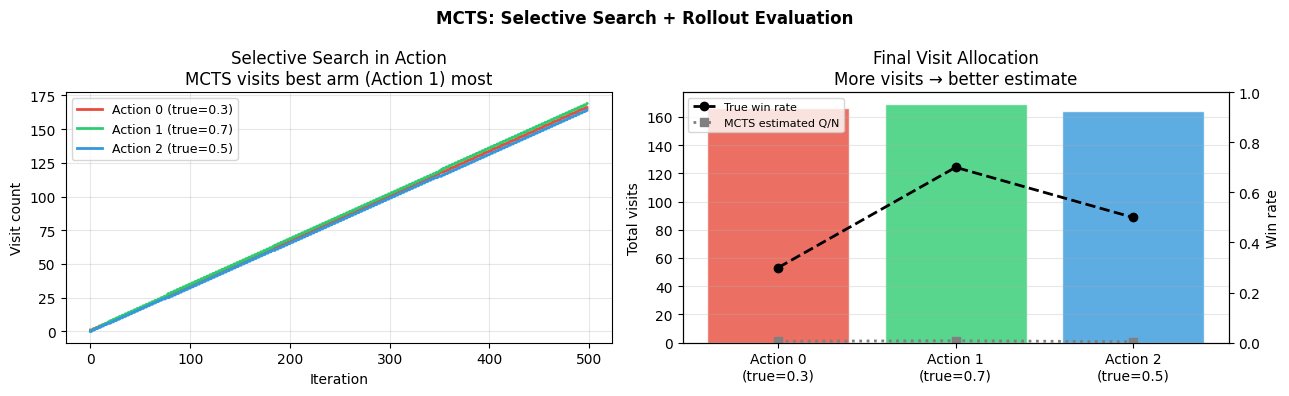

In [2]:
# =============================================================
# Visualisation 1: Visit distribution over iterations
# Shows selective search concentrating on the best arm
# =============================================================
if visit_log:
    visit_arr = np.array(visit_log)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # --- Left: visit counts over time ---
    ax = axes[0]
    colours = ['#e74c3c', '#2ecc71', '#3498db']
    for i in range(visit_arr.shape[1]):
        ax.plot(visit_arr[:, i], label=f'Action {i} (true={TRUE_WIN_RATES[i]})',
                color=colours[i], linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Visit count')
    ax.set_title('Selective Search in Action\nMCTS visits best arm (Action 1) most')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Right: final visit proportions ---
    ax = axes[1]
    if root.children:
        final_visits = [c.N for c in root.children]
        final_values = [c.Q / max(c.N, 1) for c in root.children]
        x = np.arange(len(root.children))
        bars = ax.bar(x, final_visits, color=colours[:len(root.children)],
                      alpha=0.8, edgecolor='white')
        ax2 = ax.twinx()
        ax2.plot(x, TRUE_WIN_RATES[:len(root.children)], 'k--o',
                 label='True win rate', linewidth=2)
        ax2.plot(x, final_values, 'gray', marker='s', linestyle=':',
                 label='MCTS estimated Q/N', linewidth=2)
        ax2.set_ylim(0, 1)
        ax2.set_ylabel('Win rate')
        ax2.legend(fontsize=8, loc='upper left')
        ax.set_xticks(x)
        ax.set_xticklabels([f'Action {i}\n(true={TRUE_WIN_RATES[i]})' for i in range(3)])
        ax.set_ylabel('Total visits')
        ax.set_title('Final Visit Allocation\nMore visits → better estimate')
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('MCTS: Selective Search + Rollout Evaluation', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

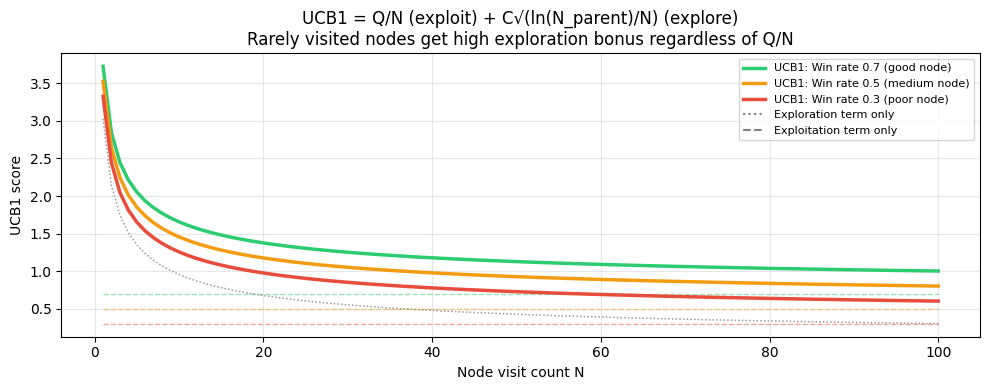

Key insight:
  When N is small → exploration term dominates → MCTS explores under-visited nodes
  When N is large → exploitation term dominates → MCTS trusts accumulated win rate
  This balance IS the selective search mechanism


In [3]:
# =============================================================
# Visualisation 2: UCB1 — exploitation vs exploration balance
# =============================================================
fig, ax = plt.subplots(figsize=(10, 4))

N_parent = 100
C = 1.41
N_range = np.arange(1, N_parent + 1)

for win_rate, colour, label in [
    (0.7, '#2ecc71', 'Win rate 0.7 (good node)'),
    (0.5, '#f39c12', 'Win rate 0.5 (medium node)'),
    (0.3, '#e74c3c', 'Win rate 0.3 (poor node)'),
]:
    Q_vals = win_rate * N_range  # total value = win_rate × visits
    ucb    = Q_vals / N_range + C * np.sqrt(np.log(N_parent) / N_range)
    exploit = Q_vals / N_range
    explore = C * np.sqrt(np.log(N_parent) / N_range)
    ax.plot(N_range, ucb,     color=colour, linewidth=2.5, label=f'UCB1: {label}')
    ax.plot(N_range, exploit, color=colour, linewidth=1,   linestyle='--', alpha=0.5)
    ax.plot(N_range, explore, color='gray', linewidth=1,   linestyle=':', alpha=0.4)

ax.set_xlabel('Node visit count N')
ax.set_ylabel('UCB1 score')
ax.set_title('UCB1 = Q/N (exploit) + C√(ln(N_parent)/N) (explore)\n'
             'Rarely visited nodes get high exploration bonus regardless of Q/N')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

explore_line = plt.Line2D([0], [0], color='gray', linestyle=':', label='Exploration term only')
exploit_line = plt.Line2D([0], [0], color='gray', linestyle='--', label='Exploitation term only')
ax.legend(handles=ax.get_legend_handles_labels()[0] + [explore_line, exploit_line],
          fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print('Key insight:')
print('  When N is small → exploration term dominates → MCTS explores under-visited nodes')
print('  When N is large → exploitation term dominates → MCTS trusts accumulated win rate')
print('  This balance IS the selective search mechanism')

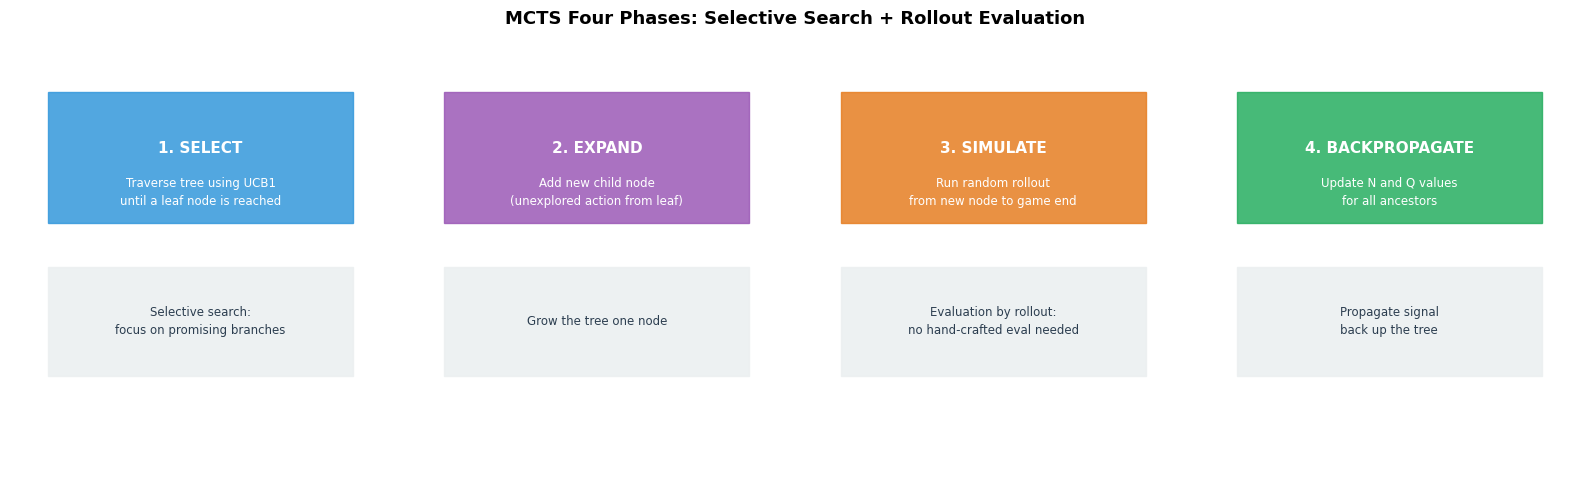

In [5]:
# =============================================================
# Visualisation 3: The 4 MCTS phases diagram
# =============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

phases = [
    ('1. SELECT', '#3498db',
     'Traverse tree using UCB1\nuntil a leaf node is reached',
     'Selective search:\nfocus on promising branches'),
    ('2. EXPAND', '#9b59b6',
     'Add new child node\n(unexplored action from leaf)',
     'Grow the tree one node'),
    ('3. SIMULATE', '#e67e22',
     'Run random rollout\nfrom new node to game end',
     'Evaluation by rollout:\nno hand-crafted eval needed'),
    ('4. BACKPROPAGATE', '#27ae60',
     'Update N and Q values\nfor all ancestors',
     'Propagate signal\nback up the tree'),
]

for ax, (title, colour, desc, note) in zip(axes, phases):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    ax.add_patch(plt.Rectangle((1, 6), 8, 3, color=colour, alpha=0.85, zorder=2))
    ax.text(5, 7.7, title, ha='center', va='center', fontsize=11,
            fontweight='bold', color='white', zorder=3)
    ax.text(5, 6.7, desc, ha='center', va='center', fontsize=8.5,
            color='white', zorder=3, linespacing=1.5)
    ax.add_patch(plt.Rectangle((1, 2.5), 8, 2.5, color='#ecf0f1', alpha=0.9, zorder=2))
    ax.text(5, 3.75, note, ha='center', va='center', fontsize=8.5,
            color='#2c3e50', zorder=3, linespacing=1.5)

fig.suptitle('MCTS Four Phases: Selective Search + Rollout Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Exam Quick-Reference

**Selective search** — MCTS uses UCB1 to choose *which* part of the tree to explore next. It balances:
- **Exploitation:** nodes with a high win rate (Q/N)
- **Exploration:** nodes that haven't been visited much yet

This concentrates computation on the most promising branches rather than wasting it on clearly bad ones.

**Evaluation by rollouts** — once a new node is reached, its value is estimated by simulating the game to completion using random moves. The result (win/loss) is a cheap, unbiased proxy for the node's true value — no hand-crafted evaluation function needed.

**Together:** Rollouts provide the value signal that selective search uses to prioritise where to look next. Each iteration refines the estimates, gradually steering exploration toward the best moves.

**One-line exam answer:** MCTS uses UCB1 to focus on promising unexplored branches (selective search), and estimates node value by simulating random game completions (rollout) — avoiding the need for an explicit evaluation function.